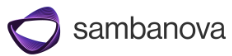

# Session 1: Build Your First Agent

**Deep Agents from Scratch** — Data Science Dojo x SambaNova

---

In this notebook, we'll build a **ReAct agent** from the ground up using LangGraph and SambaNova's MiniMax-M2.5 model.

**What we'll build:**
- A simple LLM chain (baseline — no tools, no planning, no iteration)
- A ReAct agent that can **plan**, **search the web**, **write files**, and **iterate on quality**

**The task:** *"Research a topic, create a plan, and write a summary report."*

By the end, you'll see the dramatic difference between a static chain and a dynamic agent.

In [1]:
import os
import sys
from dotenv import load_dotenv

load_dotenv(os.path.join("..", "..", ".env"), override=True)

# Add parent notebooks dir to path for utils import
sys.path.insert(0, os.path.join("..", "."))

%load_ext autoreload
%autoreload 2

In [2]:
# Validate required API keys
required_keys = ["SAMBANOVA_API_KEY", "TAVILY_API_KEY"]
missing = [k for k in required_keys if not os.environ.get(k)]
if missing:
    raise EnvironmentError(
        f"Missing required API keys: {', '.join(missing)}\n"
        f"Copy .env.example to .env and fill in your keys:\n"
        f"  cp .env.example .env"
    )
print("All required API keys present.")

All required API keys present.


### Langfuse Observability (Optional)

If you have [Langfuse](https://langfuse.com) credentials, we'll enable tracing so you can inspect every LLM call and tool invocation in the Langfuse dashboard. If not, the notebook works fine without it.

In [3]:
from langfuse.langchain import CallbackHandler

langfuse_handler = None
if os.environ.get("LANGFUSE_PUBLIC_KEY") and os.environ.get("LANGFUSE_SECRET_KEY"):
    langfuse_handler = CallbackHandler()
    print("Langfuse tracing enabled — traces will appear in your Langfuse dashboard.")
else:
    print("Langfuse keys not found — tracing disabled. Set LANGFUSE_PUBLIC_KEY and LANGFUSE_SECRET_KEY to enable.")


def get_config():
    """Build config with Langfuse callback when available."""
    if langfuse_handler:
        return {"callbacks": [langfuse_handler]}
    return {}

Langfuse tracing enabled — traces will appear in your Langfuse dashboard.


## What is a ReAct Agent?

**ReAct** = **Re**ason + **Act**

A ReAct agent follows an iterative loop:

1. **Observe** — Receive input or tool results
2. **Think** — Reason about what to do next
3. **Act** — Call a tool or produce a final answer
4. **Repeat** — Continue until the task is complete

This is what separates an *agent* from a simple LLM call: agents **plan**, **use tools**, and **iterate** to solve complex problems.

---

## Part 1: The Simple Chain (Baseline)

Let's start with a basic LLM call — no tools, no agent loop. Just ask the model directly and see what happens.

In [4]:
from langchain_sambanova import ChatSambaNova

llm = ChatSambaNova(model="MiniMax-M2.5", max_tokens=2048, temperature=0.0)

# Simple chain: just ask the LLM directly
for chunk in llm.stream(
    "Research the latest developments in AI agents, create a plan, and write a summary report.",
    config=get_config(),
):
    print(chunk.content, end="", flush=True)

<think>The user wants me to research the latest developments in AI agents, create a plan, and write a summary report. This is a comprehensive request that requires me to:

1. Research the latest developments in AI agents (as of my knowledge cutoff, I should provide current information up to my training data)
2. Create a plan related to AI agents
3. Write a summary report

Let me structure this response to cover:
- Current state of AI agents
- Latest developments and trends
- Key players and technologies
- A plan for implementing or understanding AI agents
- A comprehensive summary report

I'll provide a thorough, well-organized response that covers these aspects.
</think>

# AI Agents: Latest Developments, Plan, and Summary Report

## Part 1: Latest Developments in AI Agents

### Current State of AI Agents (2024-2025)

AI agents have evolved significantly from simple chatbots to sophisticated autonomous systems capable of reasoning, planning, and executing complex multi-step tasks.

##

> **Notice:** The chain produces a generic response from training data. No real research, no tool use, no iteration. It can't search the web, it can't save its work to files, and it can't create a structured plan. Everything comes from memory alone.

---

## Part 2: Adding Tools

Tools give agents **capabilities**. We'll define three tools that enable the full workflow:

| Tool | Purpose |
|------|--------|
| `web_search` | Search the web for current information |
| `write_todos` | Create a structured plan with tasks |
| `write_file` | Save research and reports to files |

Together these let the agent **plan** → **search** → **write** → **iterate**.

### Custom Agent State

Before defining tools, we need a custom state that can hold our TODO list and virtual file system. This extends `AgentState` with two new fields.

In [5]:
from typing import Annotated, Literal, NotRequired
from typing_extensions import TypedDict
from langchain.agents import AgentState


class Todo(TypedDict):
    """A structured task item for tracking progress."""
    content: str
    status: Literal["pending", "in_progress", "completed"]


def file_reducer(left, right):
    """Merge file dicts — new files override existing ones."""
    if left is None:
        return right
    elif right is None:
        return left
    return {**left, **right}


class DeepAgentState(AgentState):
    """Agent state with TODO tracking and a virtual file system."""
    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]


print("State schema defined: DeepAgentState with todos + files")

State schema defined: DeepAgentState with todos + files


### Tool Definitions

Now we define the three tools. Notice that `write_todos` and `write_file` return a `Command` instead of a string — this lets them **update agent state directly**. This is how tools write back to the agent's memory.

In [6]:
from langchain_core.tools import tool, InjectedToolCallId
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


@tool
def web_search(query: str) -> str:
    """Search the web for current information.

    Args:
        query: The search query string.
    """
    from tavily import TavilyClient

    client = TavilyClient()
    results = client.search(query, max_results=3)
    formatted = []
    for r in results.get("results", []):
        formatted.append(f"**{r['title']}**\n{r['content']}\nSource: {r['url']}")
    return "\n\n---\n\n".join(formatted) if formatted else "No results found."


@tool(parse_docstring=True)
def write_todos(
    todos: list[Todo],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Use this to break complex tasks into steps and track progress.
    Only one task should be in_progress at a time.

    Args:
        todos: List of Todo items with content and status.
        tool_call_id: Tool call identifier (injected).
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list: {len(todos)} items", tool_call_id=tool_call_id)
            ],
        }
    )


@tool(parse_docstring=True)
def write_file(
    file_path: str,
    content: str,
    state: Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Write content to a file in the virtual filesystem.

    Use this to save research findings, reports, or any artifacts.
    Files persist in agent state across the entire conversation.

    Args:
        file_path: Path where the file should be created/updated.
        content: Content to write to the file.
        state: Agent state (injected).
        tool_call_id: Tool call identifier (injected).
    """
    files = state.get("files", {}) or {}
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(f"Updated file: {file_path}", tool_call_id=tool_call_id)
            ],
        }
    )


tools = [web_search, write_todos, write_file]
print(f"Tools defined: {[t.name for t in tools]}")

Tools defined: ['web_search', 'write_todos', 'write_file']


---

## Part 3: Build the ReAct Agent

Now we wire everything together using `create_agent`:
- **Model**: SambaNova MiniMax-M2.5
- **Tools**: Web Search + TODO Planning + File Writing
- **State**: Custom `DeepAgentState` with todos and files
- **Prompt**: Instructions that guide the agent to plan, research, and write

The agent will automatically handle the ReAct loop — reasoning about which tools to call and when to stop.

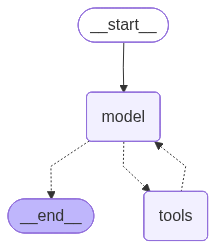

In [7]:
from langchain.agents import create_agent
from IPython.display import Image, display

SYSTEM_PROMPT = """You are a helpful research assistant with access to tools for planning, searching, and writing.

When given a research task, follow this workflow:
1. **Plan**: Use write_todos to create a structured task list
2. **Research**: Use web_search to find current, accurate information
3. **Write**: Use write_file to save your findings and final report
4. **Iterate**: Update your todo list as you complete each step

Always start by creating a plan. Save your final report to a file."""

model = ChatSambaNova(model="MiniMax-M2.5", max_tokens=2048, temperature=0.0, streaming=True)

agent = create_agent(
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=DeepAgentState,
)

# Visualize the agent graph
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

---

## Part 4: Agent vs Chain — The Same Task

Let's give the **agent** the exact same task the simple chain struggled with. Watch how the agent:
- **Plans** with a TODO list
- **Searches** the web for real information
- **Writes** its report to a file
- **Iterates** by updating its plan as it goes

In [8]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Research the latest developments in AI agents, create a plan, and write a summary report.",
            }
        ],
    },
    config=get_config(),
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Research the latest developments in AI agents, create a plan, and write a summary report.                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <think>The user wants me to research the latest developments in AI agents and create a summary report. Let me   │
│ start by creating a plan and then conducting research.                                                          │
│                                                                                                                 │
│ I'll need to:                                                                                                   │
│ 1. Create a todo list for planning                                                                              │
│ 2. Search for latest developments in AI agents                                                                  │
│ 3. Compile findings into a summary report                                                                       │
│                                                                                                                 │
│ Let me start with the planning phase.                                                                           │
│ </think>                                                                                                        │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research latest AI agent developments and trends",                                            │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Search for key AI agent products and platforms",                                              │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Find information on AI agent capabilities and use cases",                                     │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write summary report on AI agents",                                                           │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_8f835b8a10d44d70b9                                                                                  │
╰─────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list: 4 items                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <think>Now let me search for the latest developments in AI agents. I'll start with a general search about       │
│ recent AI agent developments.                                                                                   │
│ </think>                                                                                                        │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "latest developments in AI agents 2024"                                                              │
│ }                                                                                                               │
│    ID: call_5f0f0830c33342e896                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **LangChain State of AI Agents Report**                                                                         │
│ In 2024, AI agents are no longer a niche interest. Companies across industries are getting more serious about   │
│ incorporating agents into their workflows - from                                                                │
│ Source: https://www.langchain.com/stateofaiagents                                                               │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **AI Agents: Insights and Innovations in 2024 - Airweb.ai**                                                     │
│ Human-Like Reasoning: AI agents are increasingly capable of tracing their decisions, reviewing past actions,    │
│ and revising strategies based on                                                                                │
│ Source: https://airweb.ai/blog-ai-agents-insights-and-Innovations-in-2024                                       │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **AI Agents in 2024: What's Next for Autonomous Digital Assistance?**                                           │
│ AI Agents in 2024: What's Next for Autonomous Digital Assistance? · Enhanced Personalization · Improved         │
│ Contextual Understanding · Seamless Integration Across                                                          │
│ Source:                                                                                                         │
│ https://www.agentixlabs.com/blog/general/ai-agents-in-2024-whats-next-for-autonomous-digital-assistance/        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <think>Now I'll create a comprehensive summary report on AI agents based on my research.                        │
│ </think>                                                                                                        │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "content": "# Latest Developments in AI Agents: Summary Report\n\n## Executive Summary\n\nAI agents have      │
│ transitioned from experimental technology to essential business infrastructure in 2024-2025. The global AI      │
│ agents market is valued at approximately $5.4 billion in 2024 and is projected to reach $51.87 billion by 2030, │
│ representing a compound annual growth rate (CAGR) of 45.8%. With 89% of business teams already using AI agents  │
│ and the average organization running 12 agents, the technology is rapidly becoming the default operating mode   │
│ for enterprise software.\n\n---\n\n## 1. Market Overview and Adoption Trends\n\n### Market Size and Growth\n-   │
│ **Global market value**: $5.4 billion in 2024, projected to reach $7.6 billion by 2025\n- **10-year             │
│ projection**: $51.87 billion by 2030 (CAGR of 45.8%)\n- **Enterprise adoption**: 79% of firms have adopted AI   │
│ agents\n- **Productivity gains**: 66% report measurable productivity improvements\n- **Investment trends**: 88% │
│ of organizations plan to increase AI budgets within 12 months\n\n### Industry-Specific Adoption\n- **Tech       │
│ sector**: Highest adoption rates, leading in sophisticated agent implementations\n- **Financial services**:     │
│ Fraud detection, supply chain automation, personalized customer support\n- **Healthcare**: Emerging             │
│ applications in diagnostics and patient management\n- **Retail and hospitality**: Customer experience           │
│ optimization, pricing strategies, inventory management\n\n---\n\n## 2. Major Platform Developments\n\n### The   │
│ \"Agent Arms Race\"\n\nThe competitive landscape is defined by the major AI labs racing to build autonomous AI  │
│ systems that execute real-world tasks:\n\n#### OpenAI - Operator\n- Autonomous agent capable of executing tasks │
│ on behalf of users\n- Integrated with OpenAI's broader ecosystem\n- Focus on real-world task automation beyond  │
│ question-answering\n\n#### Anthropic - Claude Computer Use & Claude Code\n- **Computer Use**: Claude can        │
│ interact with computers directly, clicking, typing, and navigating interfaces\n- **Claude Code**:               │
│ Developer-focused agent for coding tasks\n- Emphasis on safe, controllable autonomous behavior\n\n#### Google - │
│ Project Mariner\n- Early research prototype built with Gemini 2.0\n- Explores human-agent interaction           │
│ paradigms\n- Focus on browser-based automation and research applications\n\n### GitHub Agent HQ\n- Microsoft's  │
│ GitHub announced a unified \"mission control\" interface\n- Allows developers to manage agents from multiple    │
│ vendors (OpenAI, Google, Anthropic, xAI, Cognition)\n- Addresses the challenge of managing multiple AI agents   │
│ across an organization\n\n---\n\n## 3. Key Capabilities and Features\n\n### Advanced Reasoning and              │
│ Decision-Making\n- **Human-like reasoning**: AI agents can trace decisions, review past actions, and revise     │
│ strategies\n- **Autonomous decision-making**: Systems capable of making decisions in real-time without human    │
│ intervention\n- **Multi-step task execution**: Handling complex workflows that require planning and             │
│ adaptation\n\n### Enterprise Automation Capabilities\n1.

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file: AI_Agents_Summary_Report.md                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <think>I've completed the research and written a comprehensive summary report. Let me update the todo list to   │
│ mark everything as completed.                                                                                   │
│ </think>                                                                                                        │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research latest AI agent developments and trends",                                            │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Search for key AI agent products and platforms",                                              │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Find information on AI agent capabilities and use cases",                                     │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write summary report on AI agents",                                                           │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_0d1f44e8d1aa4a3b82                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list: 4 items                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <think>I've completed all the tasks. Let me provide a summary to the user.                                      │
│ </think>                                                                                                        │
│                                                                                                                 │
│ I've completed the research and created a comprehensive summary report on the latest developments in AI agents. │
│ Here's what I found:                                                                                            │
│                                                                                                                 │
│ ## Key Findings                                                                                                 │
│                                                                                                                 │
│ ### Market Growth                                                                                               │
│ - **$5.4 billion** market in 2024 → projected **$51.87 billion** by 2030 (45.8% CAGR)                           │
│ - **79%** of firms have adopted AI agents                                                                       │
│ - **66%** report measurable productivity gains                                                                  │
│                                                                                                                 │
│ ### Major Players in the "Agent Arms Race"                                                                      │
│ 1. **OpenAI** - Operator (autonomous task execution)                                                            │
│ 2. **Anthropic** - Claude Computer Use & Claude Code (developer-focused)                                        │
│ 3. **Google** - Project Mariner (research prototype with Gemini 2.0)                                            │
│ 4. **GitHub** - Agent HQ (unified management platform)                                                          │
│                                                                                                                 │
│ ### Key Capabilities                                                                                            │
│ - Human-like reasoning and decision tracing                                                                     │
│ - Autonomous multi-step task execution                                                                          │
│ - Enterprise automation (data ops, customer support, supply chain, marketing)                                   │
│ - Real-time decision-making                                                                                     │
│                                                                                                                 │
│ ### Challenges                                                                                                  │
│ - Only 10% have scaled agents to production (McKinsey)                                                          │
│ - Governance, trust, and regulatory compliance concerns                                                         │
│ - Integration with existing systems                                                                             │
│                                                                                                                 │
│ The full report has been saved to **`AI_Agents_Summary_Report.md`** and covers market overview, platform        │
│ developments, capabilities, use cases, challenges, and future trends.                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Inspecting Agent State

Unlike a simple chain, our agent maintained structured state throughout. Let's look at what it produced:

In [9]:
# Inspect the TODO list
print("TODO List:")
print("=" * 50)
status_emoji = {"pending": "\u23f3", "in_progress": "\U0001f504", "completed": "\u2705"}
for todo in result.get("todos", []):
    emoji = status_emoji.get(todo["status"], "?")
    print(f"  {emoji} {todo['content']} ({todo['status']})")

# Inspect files written
print(f"\nFiles Written:")
print("=" * 50)
for file_path, content in result.get("files", {}).items():
    print(f"\n--- {file_path} ({len(content)} chars) ---")
    print(content[:1000])
    if len(content) > 1000:
        print("...[truncated]")

TODO List:
  ✅ Research latest AI agent developments and trends (completed)
  ✅ Search for key AI agent products and platforms (completed)
  ✅ Find information on AI agent capabilities and use cases (completed)
  ✅ Write summary report on AI agents (completed)

Files Written:

--- AI_Agents_Summary_Report.md (7517 chars) ---
# Latest Developments in AI Agents: Summary Report

## Executive Summary

AI agents have transitioned from experimental technology to essential business infrastructure in 2024-2025. The global AI agents market is valued at approximately $5.4 billion in 2024 and is projected to reach $51.87 billion by 2030, representing a compound annual growth rate (CAGR) of 45.8%. With 89% of business teams already using AI agents and the average organization running 12 agents, the technology is rapidly becoming the default operating mode for enterprise software.

---

## 1. Market Overview and Adoption Trends

### Market Size and Growth
- **Global market value**: $5.4 billion in 

---

### The Difference

Compare the agent's response to the simple chain above:

| | Simple Chain | Agent with Tools |
|---|---|---|
| **Planning** | None | Created a TODO list and tracked progress |
| **Research** | Training data only | Searched the web for current information |
| **Output** | Text in chat | Wrote a report to a file |
| **Iteration** | Single pass | Multiple tool calls, updated plan as it went |

This is what "deep" means: **planning, acting, observing, iterating**.

---

## Part 5: Breaking Down What We Built

Let's understand the key concepts that made this agent work.

### 1. State — The Agent's Memory

```python
class DeepAgentState(AgentState):
    todos: list[Todo]       # Structured task tracking
    files: dict[str, str]   # Virtual file system
```

State is what separates an agent from a chain. The agent can **write to** and **read from** state across multiple steps. This is how it maintains context, tracks progress, and builds artifacts over time.

### 2. Tools with `Command` — Writing Back to State

Normal tools return a string. But `write_todos` and `write_file` return a `Command` — this lets them **update agent state directly**:

```python
return Command(
    update={
        "files": files,                    # Update the virtual filesystem
        "messages": [ToolMessage(...)],     # Send confirmation back to the agent
    }
)
```

This is a powerful pattern — tools don't just return information, they **change the world** the agent operates in.

### 3. The ReAct Loop — Plan, Act, Observe, Repeat

The agent autonomously decided to:
1. Create a plan (write_todos)
2. Search for information (web_search)
3. Save findings to a file (write_file)
4. Update its plan (write_todos again)

Nobody told it the exact sequence — the **system prompt** gave it a workflow, and the **ReAct loop** let it execute iteratively.

---

## Part 6: The 5 Pillars Preview

What we built today is just the beginning. The **Deep Agents from Scratch** series covers five pillars of agent development:

| Pillar | Topic | Session |
|--------|-------|---------|
| 1 | **Orchestration** — The ReAct loop (this notebook!) | Session 1 |
| 2 | **Memory** — Persisting context across interactions | Session 3 |
| 3 | **Tools** — Extending agent capabilities | Session 4 |
| 4 | **Agent Skills** — Composable, reusable behaviors | Session 4 |
| 5 | **Evaluation** — Measuring agent performance | Session 6 |

Each session builds on the last, taking you from a simple ReAct agent to a full-featured deep agent system.

## Next Steps

- **Session 2**: Deep dive into agent architecture — understanding graphs, nodes, and edges
- **Session 3**: Adding memory and context management
- **Session 4**: Building custom tools and agent skills

See you in the next session!